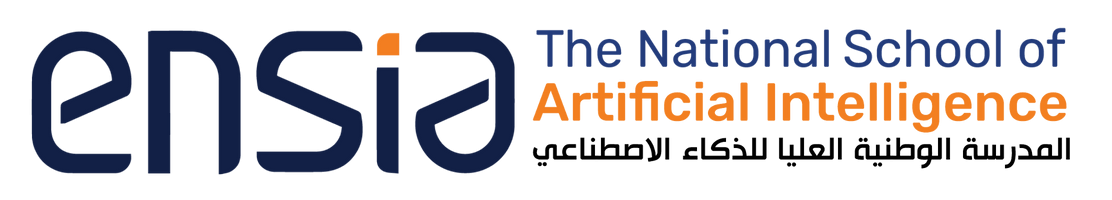

<div class="alert alert-block alert-warning">
<center>
    <h2>  The 3D Container Loading Optimizer </h2>
    <h4>A logic-based logistics tool that computes the optimal packing of 3D boxes into a standard shipping container to maximize volume utilization and stability, using Genetic Algorithms and Heuristic Search.</h4>
</center>
</div>

In [25]:
import heapq
from typing import List, Tuple, Optional
import time
from dataclasses import dataclass, field
from __future__ import annotations
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
print('All imports OK ✅')

All imports OK ✅


<div class="alert alert-block alert-warning">
<center>
    <h2> Core Classes </h2></center>
</div>

Container, Box, Space, SpaceManager, CLOProblem (container loading optimization problem)

In [26]:
@dataclass
class Container:
    """
    """
    def __init__(self, length, width, height):
        self.length = length
        self.width = width
        self.height = height
        self.boxes = []  
        self.volume = length*height*width
        # Each element: (box, x, y, z, l, w, h)
        self.used_volume = 0

    # checking if a box can be placed
    def can_place(self, box, x, y, z, l, w, h):
        # Check boundaries
        if (x + l > self.length or
            y + w > self.width or
            z + h > self.height):
            return False

        # checking overlap with existing boxes
        for (b, bx, by, bz, bl, bw, bh) in self.boxes:
            if not (x + l <= bx or bx + bl <= x or
                    y + w <= by or by + bw <= y or
                    z + h <= bz or bz + bh <= z):
                return False
        return True

    # adding a box if possible
    def add_box(self, box, position, orientation):
        x, y, z = position
        l, w, h = orientation
        if self.can_place(box, x, y, z, l, w, h):
            self.boxes.append((box, x, y, z, l, w, h))
            self.used_volume += l * w * h
            return True
        return False

    # removing a box
    def remove_box(self, index):
        b, x, y, z, l, w, h = self.boxes.pop(index)
        self.used_volume -= l * w * h

    # volume utilization (for GA / heuristics)
    def utilization(self):
        total_volume = self.length * self.width * self.height
        return self.used_volume / total_volume

    # copy (for algorithms)
    def copy(self):
        new_container = Container(self.length, self.width, self.height)
        new_container.boxes = self.boxes.copy()
        new_container.used_volume = self.used_volume
        return new_container

    # getting all possible orientations
    @staticmethod
    def get_orientations(box):
        l, w, h = box
        return list(set([
            (l, w, h), (l, h, w),
            (w, l, h), (w, h, l),
            (h, l, w), (h, w, l)
        ]))

    def get_dimensions(self):
        return (self.length, self.width, self.height)

    def summary(self):
        print("------ Container Summary ------")
        print(f"Dimensions: {self.length} x {self.width} x {self.height} cm")
        print(f"Boxes placed: {len(self.boxes)}")
        print(f"Used volume: {self.used_volume:.2f} cm³")
        print(f"Utilization: {self.utilization():.2f}%")
        print("--------------------------------")

    def __repr__(self):
        return (
            f"Container({self.length}x{self.width}x{self.height} cm, "
            f"utilization={self.utilization():.2f}%)"
        )



In [27]:
@dataclass
class Box:
    """Represents a single box to be packed."""
    id: int
    length: float
    width: float
    height: float
    weight_kg: float = 0.0
    fragile: bool = False
    
    @property
    def volume(self) -> float:
        return self.length * self.width * self.height
    
    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)
    
    def get_orientations(self) -> List[Tuple[float, float, float]]:
        """Returns all valid orientations (L, W, H permutations)."""
        l, w, h = self.length, self.width, self.height
        if self.fragile:
            # Only rotate in horizontal plane — height stays fixed
            return [(l, w, h), (w, l, h)]
        else:
            return [
                (l, w, h), (l, h, w),
                (w, l, h), (w, h, l),
                (h, l, w), (h, w, l),
            ]
    
    def __repr__(self):
        return f'Box(id={self.id}, {self.length}x{self.width}x{self.height}, fragile={self.fragile})'


In [28]:

class Space:
    """Represents a free rectangular region inside the container."""

    def __init__(self, x, y, z, l, w, h):
        self.x = x   # X position (left)
        self.y = y   # Y position (bottom / floor)
        self.z = z   # Z position (front)
        self.l = l   # Length (X dimension)
        self.w = w   # Width  (Z dimension)
        self.h = h   # Height (Y dimension)

    def volume(self):
        return self.l * self.w * self.h

    def get_fit(self, box, strategy="first"):
        """
        Try all 6 orientations of `box` and return (fits, best_dims).
        `best_dims` is the (l, w, h) tuple that fits with least wasted space.
        Returns (False, None) if no orientation fits.
        """
        bl, bw, bh = box.l, box.w, box.h

        # generating valid orientations (skip duplicates for cubes/square faces)
        orientations = set()
        for perm in [
            (bl, bw, bh), (bl, bh, bw),
            (bw, bl, bh), (bw, bh, bl),
            (bh, bl, bw), (bh, bw, bl),
        ]:
            # fragile boxes: never place with original H as L or W
            if getattr(box, "fragile", False) and perm[1] == bh:
                continue
            orientations.add(perm)

        best_dims  = None
        best_score = None

        for dims in orientations:
            l, w, h = dims
            if l <= self.l and w <= self.w and h <= self.h:
                if strategy == "first":
                    return True, dims          # return immediately on first fit
                # for "best": minimise leftover volume in this space
                score = (self.l - l) * self.w * self.h \
                      + (self.w - w) * l * self.h \
                      + (self.h - h) * l * w
                if best_score is None or score < best_score:
                    best_score = score
                    best_dims  = dims

        if best_dims:
            return True, best_dims
        return False, None

    def split(self, l, w, h):
        """
        After placing a box of size (l, w, h) at the origin of this space,
        split the remaining free volume into up to 3 non-overlapping sub-spaces.

        Classic 3-way split (guillotine):
                +---+-------+
                | B |  R1   |   R1: right of box  (full height & depth)
                +---+       |
                |   |       |
                +---+-------+
                |   R2      |   R2: in front of box (full width, remaining depth)
                +---+-------+
                    R3          R3: above box (box footprint, remaining height)
        """
        new_spaces = []

        # right of box  (x-axis remainder)
        if self.l - l > 0:
            new_spaces.append(Space(
                self.x + l, self.y, self.z,
                self.l - l, self.w, self.h
            ))

        # in front of box  (z-axis remainder)
        if self.w - w > 0:
            new_spaces.append(Space(
                self.x, self.y, self.z + w,
                l, self.w - w, self.h          # only as wide as the box (X)
            ))

        # above box  (y-axis remainder)
        if self.h - h > 0:
            new_spaces.append(Space(
                self.x, self.y + h, self.z,
                l, w, self.h - h               # only over the box footprint
            ))

        return new_spaces

    def __repr__(self):
        return (f"Space(pos=({self.x},{self.y},{self.z}) "
                f"size={self.l}×{self.w}×{self.h} "
                f"vol={self.volume()})")

In [29]:
class SpaceManager:
    """
    Tracks the collection of free (empty) rectangular spaces inside the container
    and handles placement, splitting, and cleanup of those spaces.
    """

    def __init__(self, container_space: Space):
        self.container = container_space        # keep original for reset()
        self.spaces    = [container_space]

    def reset(self):
        """Reinitialise to a fully empty container (useful between GA runs)."""
        s = self.container
        self.spaces = [Space(s.x, s.y, s.z, s.l, s.w, s.h)]

    def find_placement(self, box, strategy="best"):
        """
        Search for a free space that can hold `box`.

        Parameters
        ----------
        box      : object with attributes l, w, h (and optionally `fragile`)
        strategy : "first"  – return the first space that fits (fast, greedy)
                   "best"   – return the space that wastes the least volume
                   "bottom" – among fitting spaces prefer lowest Y then X then Z
                              (gravity / stability heuristic)

        Returns
        -------
        (space, dims) or (None, None)
        """
        best_space = None
        best_dims  = None
        best_score = None

        # Sort spaces bottom-left-front for stability-aware strategies
        search_order = self.get_sorted_spaces()

        for space in search_order:
            fits, dims = space.get_fit(box, strategy="best" if strategy != "first" else "first")

            if not fits:
                continue

            if strategy == "first":
                return space, dims

            l, w, h = dims

            if strategy == "best":
                # Minimise leftover gap in the chosen space
                score = (space.l - l) + (space.w - w) + (space.h - h)

            elif strategy == "bottom":
                # Prefer lowest Y (floor proximity), then leftmost X, then front Z
                score = (space.y * 1_000_000) + (space.x * 1_000) + space.z

            else:
                raise ValueError(f"Unknown strategy '{strategy}'")

            if best_score is None or score < best_score:
                best_score = score
                best_space = space
                best_dims  = dims

        return best_space, best_dims

    def place_box(self, space: Space, dims: tuple):
        """
        Mark `space` as occupied by a box of size `dims`,
        split the remainder into new free spaces, and clean up.

        Parameters
        ----------
        space : the Space object returned by find_placement()
        dims  : (l, w, h) tuple – the orientation chosen for the box
        """
        if space not in self.spaces:
            return

        self.spaces.remove(space)

        new_spaces = space.split(*dims)
        self.spaces.extend(new_spaces)
        self.clean_spaces()


    def free_volume(self):
        """Sum of all remaining free space volumes (may overlap – use carefully)."""
        return sum(s.volume() for s in self.spaces)

    def container_volume(self):
        return self.container.volume()

    def utilization(self, packed_volume: float) -> float:
        """
        Return packing utilisation as a percentage.

        Parameters
        ----------
        packed_volume : total volume of all boxes successfully placed so far
        """
        cv = self.container_volume()
        if cv == 0:
            return 0.0
        return (packed_volume / cv) * 100.0

    def get_sorted_spaces(self):
        """
        Return spaces sorted bottom-left-front:
            primary   → lowest Y (floor first  → gravity)
            secondary → lowest X (left first   → tighter packing)
            tertiary  → lowest Z (front first  → easier loading)
        """
        return sorted(self.spaces, key=lambda s: (s.y, s.x, s.z))

    def clean_spaces(self):
        """
        Remove:
          1. Zero/negative-volume spaces
          2. Spaces fully contained inside a larger space
        """
        # Step 1 – remove degenerate spaces
        valid = [s for s in self.spaces if s.l > 0 and s.w > 0 and s.h > 0]

        # Step 2 – remove fully-contained spaces (keep larger ones)
        cleaned = []
        for s in valid:
            dominated = any(
                other is not s and self._contains(other, s)
                for other in valid
            )
            if not dominated:
                cleaned.append(s)

        self.spaces = cleaned

    def merge_spaces(self):
        """
        Optional post-clean step: merge pairs of spaces that share two
        dimensions and are adjacent along the third.  Reduces fragmentation.

        Only run this after a full pack cycle – it is O(n²) and expensive
        to call on every placement.
        """
        merged = True
        while merged:
            merged = False
            result = []
            used   = set()

            for i, a in enumerate(self.spaces):
                if i in used:
                    continue
                for j, b in enumerate(self.spaces):
                    if j <= i or j in used:
                        continue
                    m = self._try_merge(a, b)
                    if m is not None:
                        result.append(m)
                        used.add(i)
                        used.add(j)
                        merged = True
                        break
                if i not in used:
                    result.append(a)

            self.spaces = result
    @staticmethod
    def _contains(a: Space, b: Space) -> bool:
        """Return True if space `a` fully contains space `b`."""
        return (
            a.x <= b.x and a.y <= b.y and a.z <= b.z and
            a.x + a.l >= b.x + b.l and
            a.y + a.h >= b.y + b.h and
            a.z + a.w >= b.z + b.w
        )

    @staticmethod
    def _try_merge(a: Space, b: Space):
        """
        Merge two spaces if they are adjacent along exactly one axis and
        share the same dimensions on the other two axes.
        Returns a merged Space or None.
        """
        # Adjacent along X
        if (a.y == b.y and a.z == b.z and
                a.h == b.h and a.w == b.w):
            if a.x + a.l == b.x:
                return Space(a.x, a.y, a.z, a.l + b.l, a.w, a.h)
            if b.x + b.l == a.x:
                return Space(b.x, b.y, b.z, a.l + b.l, a.w, a.h)

        # Adjacent along Y (height)
        if (a.x == b.x and a.z == b.z and
                a.l == b.l and a.w == b.w):
            if a.y + a.h == b.y:
                return Space(a.x, a.y, a.z, a.l, a.w, a.h + b.h)
            if b.y + b.h == a.y:
                return Space(b.x, b.y, b.z, a.l, a.w, a.h + b.h)

        # Adjacent along Z (depth)
        if (a.x == b.x and a.y == b.y and
                a.l == b.l and a.h == b.h):
            if a.z + a.w == b.z:
                return Space(a.x, a.y, a.z, a.l, a.w + b.w, a.h)
            if b.z + b.w == a.z:
                return Space(b.x, b.y, b.z, a.l, a.w + b.w, a.h)

        return None

    def print_spaces(self):
        print(f"SpaceManager — {len(self.spaces)} free spaces "
              f"(container vol={self.container_volume()}):")
        for s in self.get_sorted_spaces():
            print(f"  {s}")

In [30]:
@dataclass
class PackingResult:
    """Stores the result of a packing algorithm."""
    algorithm: str
    container: Container
    placed_boxes: List  # List of PlacedBox objects
    total_volume_packed: float
    execution_time_ms: float
    
    def utilization(self) -> float:
        return (self.total_volume_packed / self.container.volume) * 100
    
    def __repr__(self):
        return (f'PackingResult(algorithm={self.algorithm}, '
                f'utilization={self.utilization():.2f}%, '
                f'time={self.execution_time_ms:.2f}ms)')

In [31]:
@dataclass                          #python will directly generate its constructor __init__
class CLOProblem :
    container: Container
    seq_boxes: List[Box]
    #def __init__(self, container, seq_boxes):
     #   self.container = container
      #  self.seq_boxes = seq_boxes

    def __post_init__(self):
        """
        To check wether :
                        every box do fit in the container
                        all boxes might fit
        """
        total_box_volume=0

        for box in  self.seq_boxes:
            total_box_volume += box.volume

            if not self.fits_in_container(box, self.container):
                raise ValueError(f"Box {box.get_dimensions()} can not fit in"
                                f"Container {self.container.get_dimensions()} even with rotations!")
        
        container_volume = self.container.volume
        if total_box_volume > container_volume :
            print(  f"Warning: Total box volume ({total_box_volume}) exceeds "
                    f"container volume ({container_volume})")
        self._total_box_volume = total_box_volume
        self._container_volume = container_volume

    @property
    def total_box_volume(self):     
        return self._total_box_volume
    
    @property
    def container_volume(self):    
        return self._container_volume

    @staticmethod
    def fits_in_container(box, container):
        box_dims = sorted(box.get_dimensions())
        container_dims = sorted(container.get_dimensions())
        return all(box_dims[i]<=container_dims[i] for i in range(3))

    def get_difficulty(self) -> str:           #additional !
        """To estimate the problem difficulty"""
        ratio = self.total_box_volume / self.container_volume
        if ratio < 0.5:
            return "Easy"
        elif ratio < 0.8:
            return "Medium"
        else:
            return "Hard"

    def __repr__ (self) -> str :
        return f"""
                    Problem : {self.get_difficulty()}
                    Container: {self.container.get_dimensions()}
                    Boxes : {len(self.seq_boxes)}
                    Total box volume: {self._total_box_volume:.2f}
                    Container volume: {self._container_volume:.2f}
                """


<div class="alert alert-block alert-warning">
<center>
    <h2> Data Loading & Processing </h2></center>
</div>

In [32]:
df = pd.read_csv('../data/boxes_120(generated+local).csv')
print(f'Dataset loaded: {len(df)} boxes')
df.head(10)

Dataset loaded: 120 boxes


,id,length,width,height,weight_kg,fragile
0,1,62.0,17.0,60.0,0.020,True
1,2,15.0,12.0,6.0,0.015,True
2,3,31.0,25.0,9.0,2.000,True
3,4,61.0,43.0,8.0,0.500,True
4,5,58.0,39.0,38.0,8.000,True
5,6,34.0,34.0,53.0,20.000,True
6,7,33.0,33.0,24.0,10.000,True
7,8,16.0,16.0,5.0,0.400,True
8,9,15.0,15.0,7.0,0.005,True
9,10,35.0,26.0,35.0,8.000,True


In [33]:
# --- Check for missing values ---
print('Missing values per column:')
print(df.isnull().sum())

# --- Ensure correct types ---
df['fragile'] = df['fragile'].astype(bool)
for col in ['length', 'width', 'height', 'weight_kg']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Drop rows with invalid dimensions ---
before = len(df)
df.dropna(subset=['length', 'width', 'height', 'weight_kg'], inplace=True)
df = df[(df['length'] > 0) & (df['width'] > 0) & (df['height'] > 0) & (df['weight_kg'] >= 0)]
df.reset_index(drop=True, inplace=True)
print(f'\nRows after cleaning: {len(df)} (removed {before - len(df)} invalid rows)')

Missing values per column:
id           0
length       0
width        0
height       0
weight_kg    0
fragile      0
dtype: int64

Rows after cleaning: 120 (removed 0 invalid rows)


In [34]:
# --- Volume in cm³ ---
df['volume_cm3'] = df['length'] * df['width'] * df['height']

# --- Density (kg / cm³) ---
df['density'] = df['weight_kg'] / df['volume_cm3']

# --- Size category ---
def categorize_size(vol):
    if vol < 1000:
        return 'Small'
    elif vol < 10000:
        return 'Medium'
    else:
        return 'Large'

df['size_category'] = df['volume_cm3'].apply(categorize_size)

print('Feature engineering done ✅')
df[['id','length','width','height','weight_kg','volume_cm3','density','size_category','fragile']].head(10)

Feature engineering done ✅


,id,length,width,height,weight_kg,volume_cm3,density,size_category,fragile
0,1,62.0,17.0,60.0,0.020,63240.0,3.162555e-07,Large,True
1,2,15.0,12.0,6.0,0.015,1080.0,1.388889e-05,Medium,True
2,3,31.0,25.0,9.0,2.000,6975.0,2.867384e-04,Medium,True
3,4,61.0,43.0,8.0,0.500,20984.0,2.382768e-05,Large,True
4,5,58.0,39.0,38.0,8.000,85956.0,9.307087e-05,Large,True
5,6,34.0,34.0,53.0,20.000,61268.0,3.264347e-04,Large,True
6,7,33.0,33.0,24.0,10.000,26136.0,3.826140e-04,Large,True
7,8,16.0,16.0,5.0,0.400,1280.0,3.125000e-04,Medium,True
8,9,15.0,15.0,7.0,0.005,1575.0,3.174603e-06,Medium,True
9,10,35.0,26.0,35.0,8.000,31850.0,2.511774e-04,Large,True


In [35]:
print('=== Dataset Summary ===')
print(df[['length','width','height','weight_kg','volume_cm3']].describe().round(2))
print(f'\nFragile boxes : {df["fragile"].sum()} / {len(df)}')
print(f'Size breakdown:\n{df["size_category"].value_counts()}')

=== Dataset Summary ===
       length   width  height  weight_kg  volume_cm3
count  120.00  120.00  120.00     120.00      120.00
mean    57.25   38.79   39.96      16.32    96564.82
std     32.09   19.02   23.23      11.38   107332.42
min     10.60   10.00    5.00       0.00     1080.00
25%     30.15   25.00   17.92       5.41    24348.53
50%     49.30   33.80   40.95      14.24    61505.49
75%     85.08   54.30   59.25      30.00   118212.85
max    118.60   79.00   79.30      30.00   654476.94

Fragile boxes : 43 / 120
Size breakdown:
size_category
Large     105
Medium     15
Name: count, dtype: int64


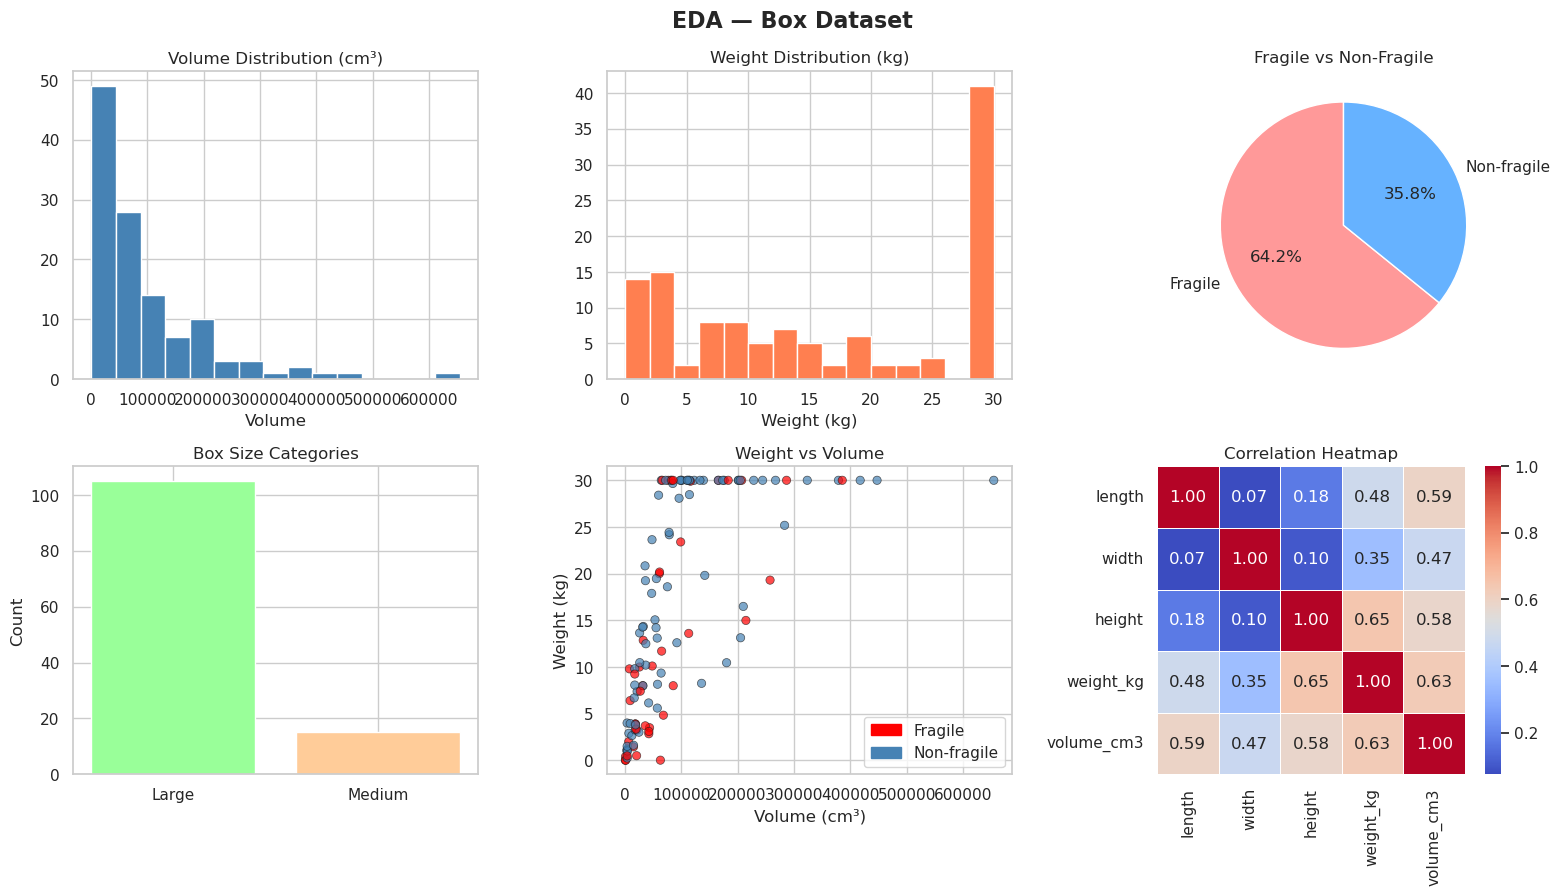

EDA plots saved ✅


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Box Dataset', fontsize=16, fontweight='bold')

# Volume distribution
axes[0,0].hist(df['volume_cm3'], bins=15, color='steelblue', edgecolor='white')
axes[0,0].set_title('Volume Distribution (cm³)')
axes[0,0].set_xlabel('Volume')

# Weight distribution
axes[0,1].hist(df['weight_kg'], bins=15, color='coral', edgecolor='white')
axes[0,1].set_title('Weight Distribution (kg)')
axes[0,1].set_xlabel('Weight (kg)')

# Fragile vs Non-fragile
counts = df['fragile'].value_counts()
axes[0,2].pie(counts, labels=['Fragile','Non-fragile'], autopct='%1.1f%%',
              colors=['#ff9999','#66b2ff'], startangle=90)
axes[0,2].set_title('Fragile vs Non-Fragile')

# Size category bar chart
size_counts = df['size_category'].value_counts()
axes[1,0].bar(size_counts.index, size_counts.values,
              color=['#99ff99','#ffcc99','#ff9999'])
axes[1,0].set_title('Box Size Categories')
axes[1,0].set_ylabel('Count')

# Weight vs Volume scatter
colors = df['fragile'].map({True: 'red', False: 'steelblue'})
axes[1,1].scatter(df['volume_cm3'], df['weight_kg'], c=colors, alpha=0.7, edgecolors='k', linewidths=0.5)
axes[1,1].set_title('Weight vs Volume')
axes[1,1].set_xlabel('Volume (cm³)')
axes[1,1].set_ylabel('Weight (kg)')
red_patch = mpatches.Patch(color='red', label='Fragile')
blue_patch = mpatches.Patch(color='steelblue', label='Non-fragile')
axes[1,1].legend(handles=[red_patch, blue_patch])

# Dimension correlation heatmap
corr = df[['length','width','height','weight_kg','volume_cm3']].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved ✅')

In [37]:
# instantiating container 
container = Container(520, 210, 210)
print(container)

# building list of Box objects from dataframe
boxes = [
    Box(
        id=int(row['id']),
        length=row['length'],
        width=row['width'],
        height=row['height'],
        weight_kg=row['weight_kg'],
        fragile=bool(row['fragile'])
    )
    for _, row in df.iterrows()
]

print(f'\nBuilt {len(boxes)} Box objects')
print('Sample:', boxes[:3])

Container(520x210x210 cm, utilization=0.00%)

Built 120 Box objects
Sample: [Box(id=1, 62.0x17.0x60.0, fragile=True), Box(id=2, 15.0x12.0x6.0, fragile=True), Box(id=3, 31.0x25.0x9.0, fragile=True)]


In [38]:
total_box_volume = df['volume_cm3'].sum()
container_volume = container.volume
utilization = (total_box_volume / container_volume) * 100

print(f'Container volume      : {container_volume:,.0f} cm³  ({container_volume/1e6:.3f} m³)')
print(f'Total box volume      : {total_box_volume:,.0f} cm³  ({total_box_volume/1e6:.3f} m³)')
print(f'Raw utilization       : {utilization:.2f}%')
print(f'\n→ We have {len(boxes)} boxes to pack.')
print(f'→ Theoretical max utilization (ignoring gaps): {utilization:.1f}%')
print(f'→ Target after optimization: ≥ 75–80%')

Container volume      : 22,932,000 cm³  (22.932 m³)
Total box volume      : 11,587,778 cm³  (11.588 m³)
Raw utilization       : 50.53%

→ We have 120 boxes to pack.
→ Theoretical max utilization (ignoring gaps): 50.5%
→ Target after optimization: ≥ 75–80%


In [39]:
df.to_csv('boxes_preprocessed.csv', index=False)
print('Saved boxes_preprocessed.csv ✅')
print(f'Final dataset shape: {df.shape}')
df.head()

Saved boxes_preprocessed.csv ✅
Final dataset shape: (120, 9)


,id,length,width,height,weight_kg,fragile,volume_cm3,density,size_category
0,1,62.0,17.0,60.0,0.020,True,63240.0,3.162555e-07,Large
1,2,15.0,12.0,6.0,0.015,True,1080.0,1.388889e-05,Medium
2,3,31.0,25.0,9.0,2.000,True,6975.0,2.867384e-04,Medium
3,4,61.0,43.0,8.0,0.500,True,20984.0,2.382768e-05,Large
4,5,58.0,39.0,38.0,8.000,True,85956.0,9.307087e-05,Large


<div class="alert alert-block alert-warning">
<center>
    <h2>  The Algorithms</h2>
</center>
</div>

## Genetic Algorithm (GA)
- Chromosome: A permutation (sequence) of boxes to pack.  
- Decoder (Heuristic): Take the sequence from the GA and place each box using a "Best Fit" logic.  
- Fitness: The total volume packed.

In [40]:
#GA here
class GAPacker:
    pass

## Greedy Heuristic (Best-Fit Decreasing)

#### Sort boxes by volume (largest first). Place each box in the first available space that fits.

##### Greedy algorithms are a class of algorithms that make locally optimal choices at each step with the hope of finding a global optimum solution.  

- At every step of the algorithm, we make a choice that looks the best at the moment.  

>>>> Placing the biggest box first  

- To make the choice, we sometimes sort the array so that we can always get the next optimal choice quickly.  

>>>> Sorting the boxes depending on the volume from biggest to smallest

- After making a choice, we check for constraints (if there are any) and keep picking until we find the solution.  
Greedy algorithms do not always give the best solution.  

<div class="alert alert-block alert-info"> 
<b>We used a priority queue to get the next optimal item.</b>
</div>

In [41]:
@dataclass
class GreedyPacker:
    """
    Greedy Best-Fit Decreasing using a max-heap (by volume).

    - Orders boxes by volume (largest first)
    - Uses SpaceManager to find placement
    """

    def pack(self, problem):
        start_time = time.time()

        # Max-heap using negative volume
        box_heap: List[Tuple[float, int, object]] = [
            (-box.volume, box.id, box) for box in problem.seq_boxes
        ]
        heapq.heapify(box_heap)

        space_manager = SpaceManager(problem.container)
        placement_sequence = []

        while box_heap:
            neg_volume, box_id, box = heapq.heappop(box_heap)

            # SpaceManager handles both space + orientation selection
            best_space, best_orientation = space_manager.find_placement(box, strategy="first")

            if best_space and best_orientation:
                placed = space_manager.place_box(
                    box,
                    best_orientation,
                    best_space
                )
                placement_sequence.append(placed)

        execution_time_ms = (time.time() - start_time) * 1000

        return PackingResult(
            algorithm="Greedy Best-Fit Decreasing (Heap)",
            container=problem.container,
            placed_boxes=placement_sequence,
            total_volume_packed=space_manager.get_packed_volume(),
            execution_time_ms=execution_time_ms
        )

## Simulated Annealing

### What is Simulated Annealing?

Imagine you're trying to find the lowest point in a hilly landscape — blindfolded.  
A simple strategy: always step downhill. But this gets you **stuck in small valleys** (local optima).  

Simulated Annealing's strategy: **sometimes take a step uphill on purpose**, especially early on.  
As time goes on, you take fewer and fewer uphill steps until you only go downhill.  
This way you **escape local optima** and find a much better valley (global optimum).  

The name comes from **metallurgy**: when you heat metal and let it cool slowly,  
atoms settle into a strong, low-energy structure. Fast cooling = weak metal. Slow cooling = strong metal.  
We do the same with our solution.  

---
### How it works in our project:

1. Start with a random order (sequence) of boxes
2. Pack them into the container using a heuristic → measure how full it is (**fitness**)
3. **Perturb**: randomly swap two boxes in the sequence
4. Pack again → measure new fitness
5. If new is better → accept it
6. If new is worse → **maybe accept it anyway** (based on temperature)
7. Slowly lower the temperature → repeat thousands of times
8. Return the best solution found

In [42]:
#SA here
class SAPAcker :
    pass

<div class="alert alert-block alert-warning">
<center>
    <h2>  Testing </h2>
</center>
</div>

In [45]:
def test_greedy():
    """
    Test the Greedy Packer using:
    - Loaded box data from CSV (120 boxes)
    - Container dimensions (520 x 210 x 210 cm)
    """
    print("=" * 70)
    print(" TESTING GREEDY PACKER WITH LOADED DATA")
    print("=" * 70)
    
    # STEP 1: instantiating Container
    
    CONTAINER_LENGTH = 520.0  # cm
    CONTAINER_WIDTH = 210.0   # cm  
    CONTAINER_HEIGHT = 210.0  # cm
    
    container = Container(
        length=CONTAINER_LENGTH,
        width=CONTAINER_WIDTH,
        height=CONTAINER_HEIGHT
    )
    
    print(f"\n📦 Container:")
    print(f"   Dimensions: {container.length} x {container.width} x {container.height} cm")
    print(f"   Volume: {container.volume:,.0f} cm³ ({container.volume/1e6:.2f} m³)")
    
    # STEP 2: creating Box objects from DataFrame
    
    print(f"\n📋 Creating Box objects from {len(df)} rows...")
    
    boxes = []
    for _, row in df.iterrows():
        boxes.append(Box(
            id=int(row['id']),
            length=row['length'],
            width=row['width'],
            height=row['height'],
            weight_kg=row['weight_kg'],
            fragile=bool(row['fragile'])
        ))
    
    print(f"   ✅ Created {len(boxes)} Box objects")
    

    # STEP 3: creating an instance of Problem 
    
    try:
        problem = CLOProblem(container=container, seq_boxes=boxes)
        print(f"\n📊 Problem Summary:{problem}")
    except ValueError as e:
        print(f"\n❌ Validation failed: {e}")
        return None, None
    
    # STEP 4: running Greedy Packer
    
    print("\n🔄 Running Greedy Packer (Best-Fit Decreasing)...")
    packer = GreedyPacker()
    result = packer.pack(problem)
    
    # STEP 5: displaying the results
    
    print("\n" + "=" * 70)
    print("📊 RESULTS")
    print("=" * 70)
    
    print(f"\n🎯 Algorithm: {result.algorithm}")
    print(f"\n📦 Packing Statistics:")
    print(f"   Total boxes          : {len(boxes)}")
    print(f"   Boxes placed         : {len(result.placed_boxes)}")
    print(f"   Placement rate       : {(len(result.placed_boxes)/len(boxes))*100:.1f}%")
    print(f"\n📐 Volume Statistics:")
    print(f"   Volume packed        : {result.total_volume_packed:,.0f} cm³ ({result.total_volume_packed/1e6:.2f} m³)")
    print(f"   Container volume     : {result.container.volume:,.0f} cm³ ({result.container.volume/1e6:.2f} m³)")
    print(f"   Volume utilization   : {result.utilization():.2f}%")
    print(f"\n⏱️  Execution time       : {result.execution_time_ms:.2f} ms")
    
    # STEP 6: Theoretical analysis
    
    total_box_volume = problem.total_box_volume
    theoretical_max = (total_box_volume / container.volume) * 100
    
    print(f"\n📈 Theoretical Analysis:")
    print(f"   Total volume of all boxes: {total_box_volume:,.0f} cm³ ({total_box_volume/1e6:.2f} m³)")
    print(f"   Theoretical max utilization: {theoretical_max:.2f}%")
    print(f"   Achieved utilization: {result.utilization():.2f}%")
    print(f"   Gap to optimum: {theoretical_max - result.utilization():.2f}%")
    
    # STEP 7: Sample of placed boxes
    print(f"\n📦 Sample placed boxes (first 10):")
    print("   ID  | Pos (x, y, z)     | Dimensions (l×w×h)    | Volume  | Fragile")
    print("   " + "-" * 70)
    
    for i, placed in enumerate(result.placed_boxes[:10]):
        fragile_mark = "⚠️" if placed.box.fragile else "✓"
        vol = placed.l * placed.w * placed.h
        print(f"   {placed.box.id:3d} | ({placed.x:5.0f},{placed.y:5.0f},{placed.z:5.0f}) | "
              f"{placed.l:5.0f}×{placed.w:5.0f}×{placed.h:5.0f} | "
              f"{vol:8,.0f} | {fragile_mark}")
    
    if len(result.placed_boxes) > 10:
        print(f"   ... and {len(result.placed_boxes) - 10} more boxes")
    
    # STEP 8: Fragile box analysis
    
    fragile_placed = sum(1 for p in result.placed_boxes if p.box.fragile)
    fragile_total = sum(1 for b in boxes if b.fragile)
    fragile_volume_placed = sum(p.l * p.w * p.h for p in result.placed_boxes if p.box.fragile)
    
    print(f"\n🔍 Fragile Box Analysis:")
    print(f"   Fragile boxes placed   : {fragile_placed} / {fragile_total}")
    print(f"   Fragile volume placed  : {fragile_volume_placed:,.0f} cm³")
    if fragile_placed > 0:
        avg_height = sum(p.y for p in result.placed_boxes if p.box.fragile) / fragile_placed
        print(f"   Average Y position (height) of fragile boxes: {avg_height:.1f} cm (lower = better)")
    
    # STEP 9: Validation checks
    
    print(f"\n🔧 Running validation checks...")
    
    # Check overlaps
    no_overlap = True
    for i, p1 in enumerate(result.placed_boxes):
        for p2 in result.placed_boxes[i+1:]:
            if not (p1.x + p1.l <= p2.x or p2.x + p2.l <= p1.x or
                    p1.y + p1.w <= p2.y or p2.y + p2.w <= p1.y or
                    p1.z + p1.h <= p2.z or p2.z + p2.h <= p1.z):
                no_overlap = False
                print(f"   ❌ Overlap between Box {p1.box.id} and Box {p2.box.id}")
    
    print(f"   No overlaps: {'✅ PASS' if no_overlap else '❌ FAIL'}")
    
    # Check boundaries
    boundaries_ok = True
    for placed in result.placed_boxes:
        if (placed.x + placed.l > container.length or
            placed.y + placed.w > container.width or
            placed.z + placed.h > container.height):
            boundaries_ok = False
            print(f"   ❌ Box {placed.box.id} exceeds container boundaries")
    
    print(f"   Within boundaries: {'✅ PASS' if boundaries_ok else '❌ FAIL'}")
    
    # Check gravity (floating boxes)
    floating = []
    for placed in result.placed_boxes:
        if placed.y > 0:
            supported = False
            for other in result.placed_boxes:
                if other is placed:
                    continue
                if (other.y + other.w == placed.y and
                    max(placed.x, other.x) < min(placed.x + placed.l, other.x + other.l) and
                    max(placed.z, other.z) < min(placed.z + placed.h, other.z + other.h)):
                    supported = True
                    break
            if not supported:
                floating.append(placed.box.id)
    
    print(f"   No floating boxes: {'✅ PASS' if not floating else f'⚠️ {len(floating)} floating'}")
    
    # STEP 10: Success Criteria Evaluation
    
    print(f"\n🎯 Success Criteria Evaluation:")
    print("   " + "-" * 50)
    
    valid = no_overlap and boundaries_ok
    print(f"   Valid packing plan: {'✅ PASS' if valid else '❌ FAIL'}")
    
    meets_target = result.utilization() >= 75.0
    print(f"   Utilization ≥ 75%: {'✅ PASS' if meets_target else f'⚠️ ({result.utilization():.1f}%)'}")
    
    # Stability: average height of fragile vs non-fragile (lower fragile = better)
    if len(result.placed_boxes) > 0:
        fragile_heights = [p.y for p in result.placed_boxes if p.box.fragile]
        normal_heights = [p.y for p in result.placed_boxes if not p.box.fragile]
        if fragile_heights and normal_heights:
            stable = sum(fragile_heights)/len(fragile_heights) <= sum(normal_heights)/len(normal_heights)
            print(f"   Stability (fragile boxes lower): {'✅ PASS' if stable else '⚠️ CAN IMPROVE'}")
    
    print("\n" + "=" * 70)
    print("✅ TEST COMPLETE")
    print("=" * 70)
    
    return result


# ============================================================================
if __name__ == "__main__":
    # Make sure df is already loaded from your CSV
    result = test_greedy_with_loaded_data()
    
    # Optional: Save for visualization
    if result:
        import json
        with open('greedy_packing_result.json', 'w') as f:
            json.dump(result.to_json(), f, indent=2)
        print("\n💾 Results saved to 'greedy_packing_result.json'")

🧪 TESTING GREEDY PACKER WITH LOADED DATA

📦 Container:
   Dimensions: 520.0 x 210.0 x 210.0 cm
   Volume: 22,932,000 cm³ (22.93 m³)

📋 Creating Box objects from 120 rows...
   ✅ Created 120 Box objects

📊 Problem Summary:
                    Problem : Medium
                    Container: (520.0, 210.0, 210.0)
                    Boxes : 120
                    Total box volume: 11587778.45
                    Container volume: 22932000.00
                

🔄 Running Greedy Packer (Best-Fit Decreasing)...


AttributeError: 'Container' object has no attribute 'y'

<div class="alert alert-block alert-warning">
<center>
    <h2>  Comparative Evaluation </h2>
</center>
</div>
